# 🔍 Phase 3 — Stock Universe Selection
**Volatility · Trend (STL) · Correlation · Sector Rationale → Final 8 Stocks**

In [1]:
from pathlib import Path
import os

# Change to project root if running from notebooks folder
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

BASE = Path('.')
RAW = BASE / 'data/raw'

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
from statsmodels.tsa.seasonal import STL

BASE = Path('.')
RAW  = BASE/'data/raw'
OUT  = BASE/'outputs/charts/phase3'
RPT  = BASE/'outputs/reports'
OUT.mkdir(parents=True, exist_ok=True)

TICKERS = {
    'HDFCBANK.NS':'HDFC Bank','ICICIBANK.NS':'ICICI Bank',
    'INFY.NS':'Infosys','TCS.NS':'TCS',
    'SUNPHARMA.NS':'Sun Pharma','DRREDDY.NS':"Dr Reddy's",
    'HINDUNILVR.NS':'HUL','ITC.NS':'ITC',
    'MARUTI.NS':'Maruti','TATAMOTORS.NS':'Tata Motors',
}
stock_data = {t: pd.read_csv(RAW/f'{t}.csv',index_col='Date',parse_dates=True)
              for t in TICKERS}
print('✅ Data loaded for Phase 3')

✅ Data loaded for Phase 3


## Step 1: Rolling Volatility Analysis

In [3]:
vol_summary = {}
for t, df in stock_data.items():
    r = df['Close'].pct_change().dropna()
    rv30 = r.rolling(30).std() * np.sqrt(252)
    vol_summary[TICKERS[t]] = {
        'Mean_AnnVol_%': round(rv30.mean()*100, 2),
        'Max_AnnVol_%':  round(rv30.max()*100, 2),
        'Min_AnnVol_%':  round(rv30.min()*100, 2),
        'Current_Vol_%': round(rv30.iloc[-1]*100, 2),
    }
display(pd.DataFrame(vol_summary).T.sort_values('Mean_AnnVol_%'))

,Mean_AnnVol_%,Max_AnnVol_%,Min_AnnVol_%,Current_Vol_%
HUL,17.74,29.73,9.42,24.50
TCS,19.71,31.58,12.48,17.00
HDFC Bank,21.75,32.07,14.10,27.84
Infosys,22.76,30.68,12.79,22.59
ITC,24.33,36.01,15.00,19.55
ICICI Bank,27.04,39.10,15.86,28.83
Maruti,27.39,43.40,15.36,30.47
Dr Reddy's,28.59,46.82,16.17,24.03
Sun Pharma,28.77,45.33,16.66,35.02
Tata Motors,40.56,57.83,22.54,33.36


## Step 2: STL Trend Decomposition

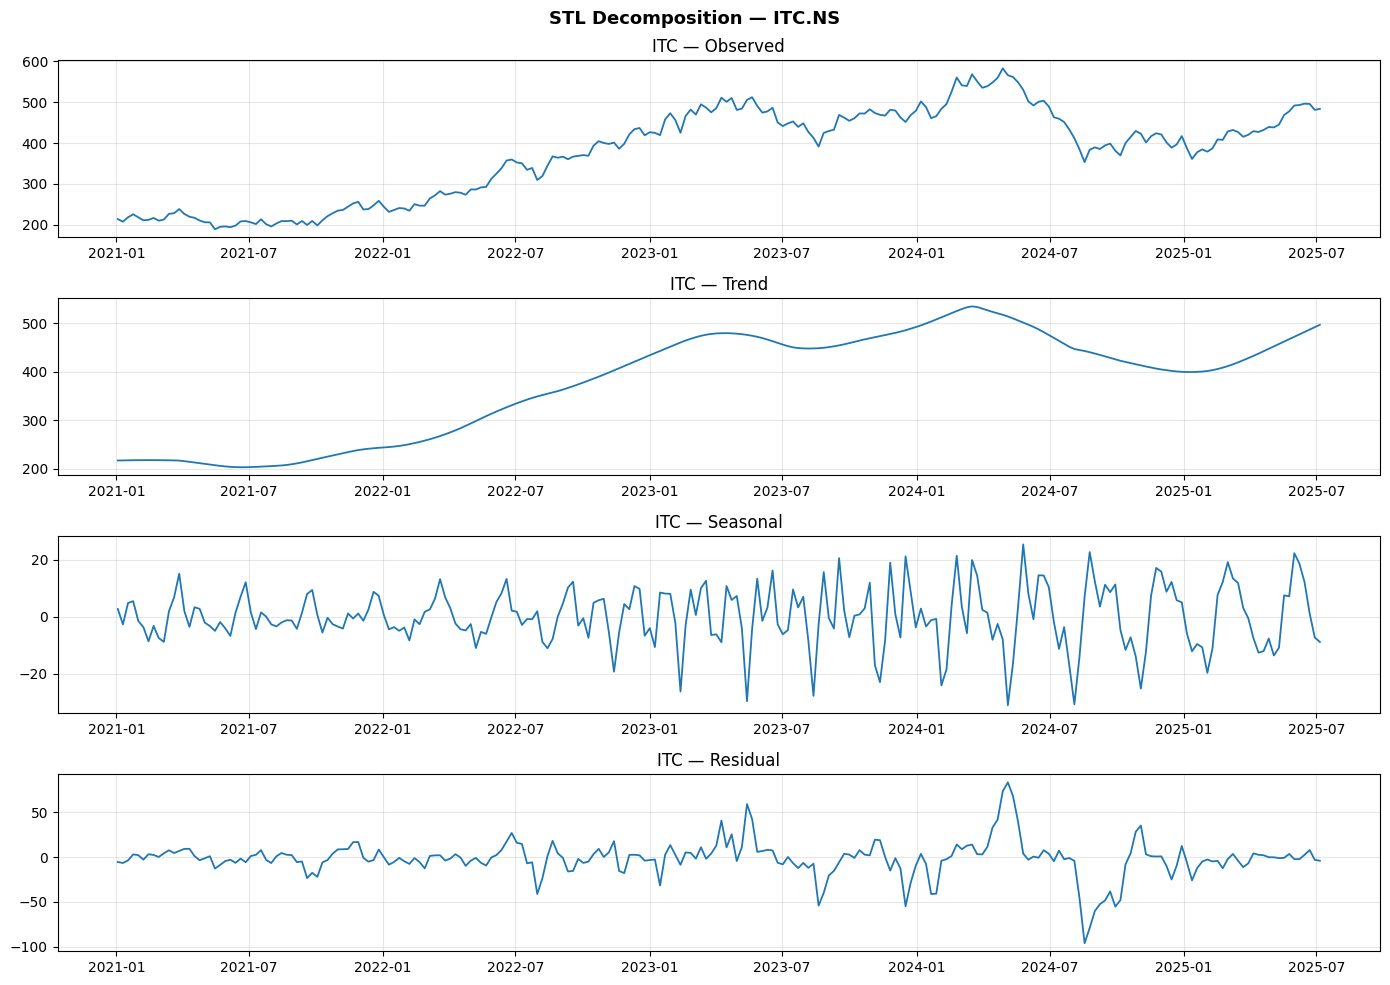

In [4]:
# STL for one representative stock
t = 'ITC.NS'
weekly = stock_data[t]['Close'].resample('W').last().dropna()
stl = STL(weekly, period=13, robust=True)
res = stl.fit()
fig, axes = plt.subplots(4,1,figsize=(14,10))
for ax, data, title in zip(axes,
    [weekly, res.trend, res.seasonal, res.resid],
    ['Observed','Trend','Seasonal','Residual']):
    ax.plot(weekly.index, data, linewidth=1.3)
    ax.set_title(f'ITC — {title}'); ax.grid(True, alpha=0.3)
plt.suptitle('STL Decomposition — ITC.NS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'stl_itc.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3: Correlation + Final Selection

In [5]:
# Load saved selection
score_df = pd.read_csv(RPT/'stock_selection_scores.csv', index_col=0)
just_df  = pd.read_csv(RPT/'phase3_stock_justification_table.csv')
selected = pd.read_csv(RPT/'selected_tickers.csv')['Ticker'].tolist()

print('\n📋 FINAL SELECTION JUSTIFICATION')
print('='*80)
display(just_df[['Company','Sector','Total_Return_%','Ann_Volatility_%',
                 'Sharpe_Ratio','ADX_Trend_Str','Forecastability',
                 'Composite_Score','Selection_Reason']])
print(f'\n✅ Final portfolio: {len(selected)} stocks selected')


📋 FINAL SELECTION JUSTIFICATION


,Company,Sector,Total_Return_%,Ann_Volatility_%,Sharpe_Ratio,ADX_Trend_Str,Forecastability,Composite_Score,Selection_Reason
0,ITC,FMCG,126.1%,24.7%,0.620,24.0,★★☆ Moderate,7.82,"Strongest Sharpe (0.62), low volatility, FMCG ..."
1,Sun Pharma,Pharma,114.5%,29.2%,0.526,36.1,★★★ Easy,7.32,"Highest ADX trend strength, defensive pharma l..."
2,Tata Motors,Auto,157.7%,41.2%,0.575,18.5,★★☆ Moderate,6.59,"Highest total return (157%), auto cyclical alpha"
3,ICICI Bank,Banking,60.0%,27.5%,0.302,32.7,★★★ Easy,5.90,"Banking sector must-have, high ADX, strong growth"
4,Infosys,IT,68.3%,23.1%,0.361,20.1,★★☆ Moderate,5.42,"IT sector representative, lower vol than peers"
5,Maruti,Auto,59.7%,28.0%,0.300,24.4,★★☆ Moderate,4.98,"Auto diversifier, market share dominance hedge"
6,Dr Reddy's,Pharma,34.6%,29.1%,0.168,19.0,★★☆ Moderate,3.79,"Second pharma for sector depth, global exposure"
7,HDFC Bank,Banking,23.7%,22.2%,0.056,16.1,★★☆ Moderate,3.60,"Most liquid NSE stock, portfolio stability anchor"



✅ Final portfolio: 8 stocks selected
